<a href="https://colab.research.google.com/github/Vanisha-18/AIML_Projects-Labs/blob/main/Copy_of_AIML__Module_4_Lab_1_Perceptron_and_Gradient_Descent_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Training Program on AIML**
# Module 4: Perceptron and Gradient Descent
## Lab 1: Perceptron

In this lab, we will be studying the perceptron learning algorithm.

# Perceptron

The Perceptron is one of the earliest and simplest types of supervised learning algorithms for binary classification.  
Think of it as the most basic form of a neuron, the fundamental building block of modern neural networks.  
Its job is to decide whether an input belongs to one class or another.  

The key idea is to find a **linear separator** (a line, a plane, or a hyperplane in higher dimensions) that can perfectly separate the data points of two classes.  

---

## The Mathematics of a Linear Separator

A line in 2D can be represented by the equation:

$$
w_1x_1 + w_2x_2 + b = 0
$$

Here:

- $(x_1, x_2)$ are the coordinates of a point (our input features).  
- $(w_1, w_2)$ are the weights. This vector $w = [w_1, w_2]$ is a normal vector to the line, meaning it's perpendicular to the line and points in a certain direction. It controls the slope of the line.  
- $b$ is the bias term. It controls the offset or position of the line (how far it is from the origin).  
---

## Making a Prediction

How do we use this line to classify a new point $x$?  
We compute the value of:

$$
z = w \cdot x + b
$$

The sign of this value tells us which side of the line the point lies on:

- If $w \cdot x + b > 0$, we predict class **+1**.  
- If $w \cdot x + b < 0$, we predict class **-1**.  

This prediction function is often written as:

$$
\hat{y} = \text{sign}(w \cdot x + b)
$$

---

## The "Bias Trick"

To simplify our equations, we can merge the bias $b$ into the weight vector $w$.  
We do this by adding a constant feature (usually $1$ or $-1$) to every input vector $x$.  

If we set $w_0 = b$ and add a feature $x_0 = 1$ to our input vector, the equation becomes:

$$
w_1x_1 + w_2x_2 + w_0x_0 = w \cdot x
$$

Now, our weight vector is:

$$
w = [w_1, w_2, b]
$$

and our input is:

$$
x = [x_1, x_2, 1]
$$

This makes the math and the code cleaner, as we only need to handle one vector $w$.


### Setting up our Toy Dataset

In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

Let's start by defining a simple, labeled dataset. It's a "toy" dataset because it's small and easy to visualize, perfect for understanding the algorithm.

Our dataset X will have 5 points, each with two features (x1, x2).

In [2]:
X = np.array([
    [-2, 4],
    [4, 1],
    [1, 6],
    [2, 4],
    [6, 2]
])

Next we need to add a bias term -1 into the data set.

In [3]:
X = np.array([
    [-2, 4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],
])

In [4]:
y = np.array([-1, -1, 1, 1, 1])

This small toy data set contains two samples labeled with −1 and three samples labeled with +1. This means we have a binary classification problem, as the data set contains two sample classes. Lets plot the dataset to see, that is is linearly seperable

Now, let's apply the bias trick. We will add a constant feature of -1 to each data point. This value will be multiplied by the bias weight.

In [5]:
# Adding the bias term (-1) to each sample

X = np.array([
    [-2, 4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],
])

Our small toy dataset contains two samples labeled with -1 (let's call them the "negative class") and three samples labeled with +1 (the "positive class"). This is a binary classification problem.

Let's plot the dataset to see if it is linearly separable, meaning we can draw a single straight line to separate the two classes.

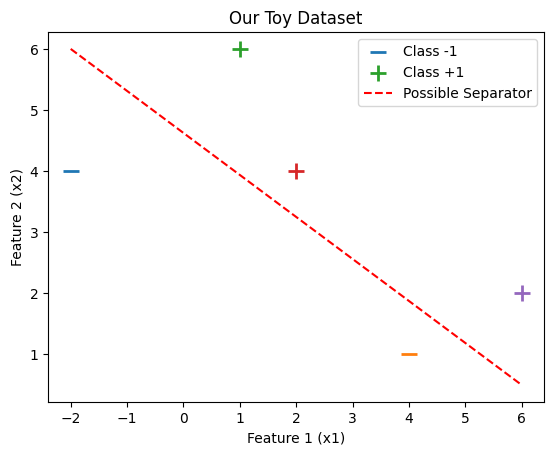

In [6]:
for d, sample in enumerate(X):
    # Plot the negative samples
    if y[d] == -1:
        plt.scatter(sample[0], sample[1], s=120, marker='_', linewidths=2, label='Class -1' if d==0 else "")
    # Plot the positive samples
    else:
        plt.scatter(sample[0], sample[1], s=120, marker='+', linewidths=2, label='Class +1' if d==2 else "")

# Add labels and a legend
plt.xlabel('Feature 1 (x1)')
plt.ylabel('Feature 2 (x2)')
plt.title('Our Toy Dataset')
plt.legend()

# For visualization, let's draw a potential separating line
# This is just a guess to show what we are looking for.
plt.plot([-2, 6], [6, 0.5], 'r--', label='Possible Separator')
plt.legend()
plt.show()

### The Perceptron Learning Algorithm

# Perceptron Learning Algorithm

The algorithm learns the optimal weights iteratively. It starts with a guess for the weights (usually all zeros) and then repeatedly adjusts them for each data sample it misclassifies.

The core of the algorithm is the update rule. When the model makes a mistake on a sample $(x_i, y_i)$, it updates the weight vector $w$ as follows:

$$
w_{\text{new}} = w_{\text{old}} + \eta \cdot y_i \cdot x_i
$$

Where:  
- $\eta$ (eta) is the learning rate, a parameter that controls the size of the weight adjustments. We'll set it to 1 for simplicity.  
- $y_i$ is the true label of the sample (+1 or -1).  
- $x_i$ is the feature vector of the sample.  

**Intuition behind the update:**  
- If a positive point $(y_i = +1)$ is misclassified as negative, it means $w \cdot x_i$ was negative. The update rule adds $\eta \cdot x_i$ to $w$, "nudging" $w$ to be more aligned with $x_i$, thus making their dot product larger and more likely to be positive next time.  
- If a negative point $(y_i = -1)$ is misclassified as positive, it means $w \cdot x_i$ was positive. The update rule subtracts $\eta \cdot x_i$ from $w$, "pushing" $w$ away from $x_i$, thus making their dot product smaller and more likely to be negative next time.  

A mistake is identified if the sign of the prediction does not match the sign of the true label. Mathematically, this happens when:

$$
(w \cdot x_i) \cdot y_i \le 0
$$


Finally we can code our Perceptron algorithm using our update rule. To keep it simple, we will linearly loop over the sample set. For larger data sets it makes sence, to randomly pick a sample during each iteration in the for-loop.

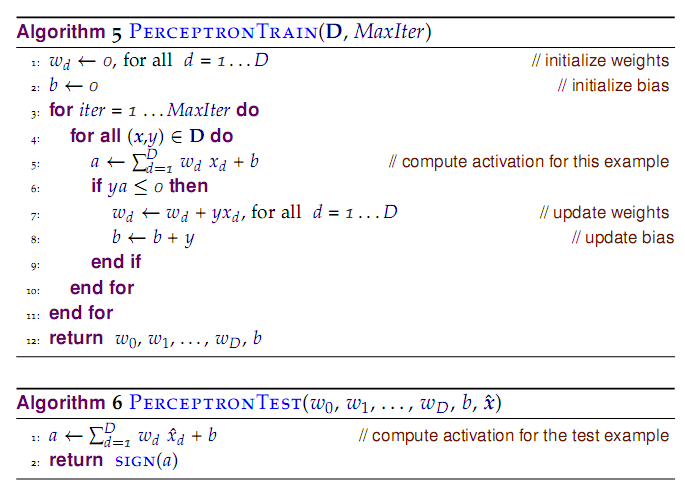

The algorithm is shown in the above image.

In [7]:
def perceptron_algo(X, Y):
    w = np.zeros(len(X[0]))
    eta = 1
    epochs = 10

    for epoch in range(epochs):
        for i, x in enumerate(X):
            if (np.dot(X[i], w) * Y[i]) <= 0:
                w = w + eta * X[i] * Y[i]
    return w

### Tracking Error During Training



To see how the learning progresses, it's useful to measure the error at each epoch.  

A common way to quantify the error for the Perceptron is to sum up the values of

$$
-(w \cdot x_i) y_i
$$

for all misclassified points. This value is always positive for misclassified points and gives us a sense of "how wrong" the model is.

Let's write a modified version of our function that **stores and plots this error for each epoch**.


In [8]:
def perceptron_algo_plot(X, Y):
    '''
    train perceptron and plot the total loss in each epoch.

    :param X: data samples
    :param Y: data labels
    :return: weight vector as a numpy array
    '''
    w = np.zeros(len(X[0]))
    eta = 1
    n = 30
    errors = []

    for t in range(n):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(X[i], w) * Y[i]) <= 0:
                total_error += (np.dot(X[i], w) * Y[i])
                w = w + eta * X[i] * Y[i]
        errors.append(total_error * -1)

    plt.plot(errors)
    plt.xlabel('Epoch')
    plt.ylabel('Total Loss')

    return w

Next, we will call this function to train our model and see the training error at each epoch.

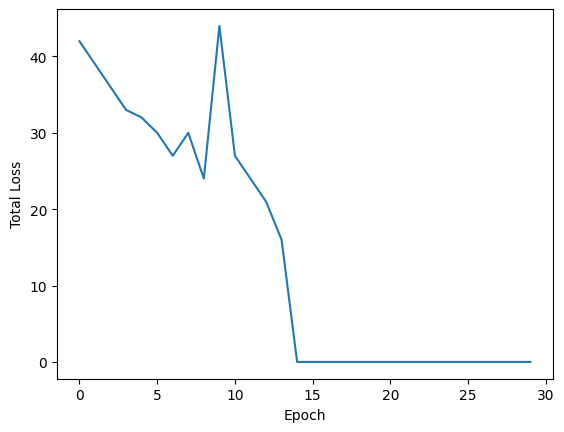

In [9]:
w = perceptron_algo_plot(X, y)

The plot shows that the total error drops to zero after just a few epochs. This is a visual confirmation that our algorithm has successfully learned a separating hyperplane and has converged. For linearly separable data, the Perceptron algorithm is guaranteed to converge.

We now plot the decision boundary and check which samples have been classified as positive and which samples have been classified as negative.

### Visualizing the Learned Decision Boundary

Now that the training is complete, we have a final weight vector w. This vector defines our decision boundary. Let's plot this boundary along with our data points to see how well it separates them. We will also add a couple of new "test" points to see how our trained model would classify them.

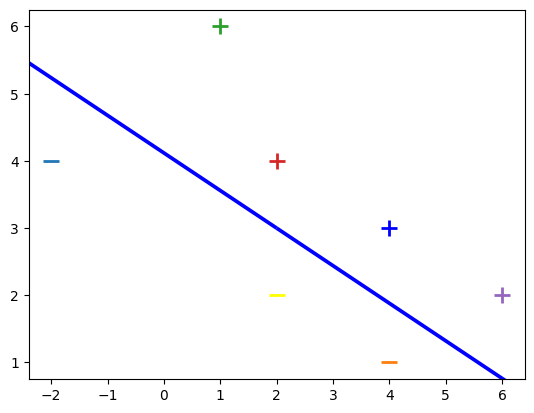

In [10]:
for d, sample in enumerate(X):
    # Plot the negative samples
    if d < 2:
        plt.scatter(sample[0], sample[1], s=120, marker='_', linewidths=2)
    # Plot the positive samples
    else:
        plt.scatter(sample[0], sample[1], s=120, marker='+', linewidths=2)

# Add our test samples

plt.scatter(2, 2, s=120, marker='_', linewidths=2, color='yellow')
plt.scatter(4, 3, s=120, marker='+', linewidths=2, color='blue')

# Print the hyperplane calculated by perceptron_sgd()
x2 = [w[0], w[1], -w[1], w[0]]
x3 = [w[0], w[1], w[1], -w[0]]

x2x3 = np.array([x2, x3])
X, Y, U, V = zip(*x2x3)
ax = plt.gca()
ax.quiver(X, Y, U, V, scale=1, color='blue')

As you can see, our algorithm has correctly classified all the samples. The decision boundary is shown in blue. The decision boundary (which is perpendicular to the blue vector) separates the + and _ classes. The yellow test point falls on the negative side, and the blue test point falls on the positive side, just as we would expect.

# Things to try


1.   Try this on a real dataset like the Sonar dataset or the Banknote Dataset and show the error plot.
2.   Increase/decrease the learning rate to see how many iterations will be take to coverge. Does it even converge on a huge learning rate?
4. Take a toy dataset that is not linearly separable and run the perceptron algorithm on it. What happens? Note your observations. An example is given below.

Dataset Links:


*   https://www.kaggle.com/datasets/rupakroy/sonarcsv
*   https://www.kaggle.com/datasets/shanks0465/banknoteauthentication



In [11]:
X = np.array([
    [-2, 4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],
])

In [12]:
y = np.array([-1, -1, 1, -1, -1]) # Note that the 4th sample's label is now -1, making the data non-linearly separable.

[-2.  3. 15.]


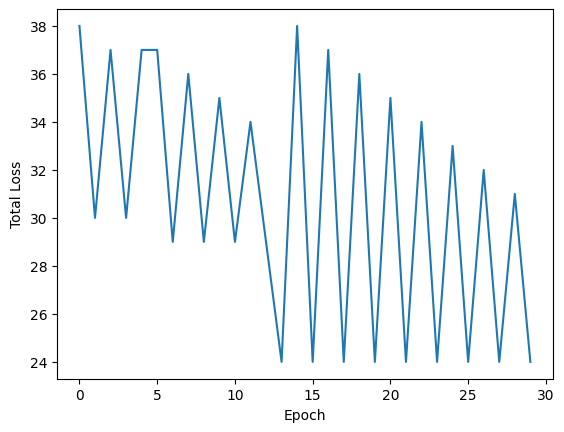

In [13]:
print(perceptron_algo_plot(X, y))

**Observation:** If the training data is not Linearly Separable, the perceptron algorithm will not converge. The error will never stay at zero. The weights will keep getting updated in a cycle as the algorithm tries to correctly classify one point, which in turn causes another point to be misclassified. the perceptron algorithm will eventually repeat the same set of weights and thereby enter an infinite loop. This demonstrates the primary limitation of the Perceptron model.

# **Things to try**

# **Tank 1 & 2 (Sonar Dataset)**

Please upload the 'sonar.csv' file.


Saving sonar.csv to sonar.csv

Training Perceptron on Sonar dataset...
Learned weights for Sonar dataset: [ 1.7233e+00  8.8770e-01  1.3247e+00  6.4496e+00  4.2276e+00  2.8840e-01
  1.4272e+00 -7.4435e+00 -5.1508e+00  1.9844e+00 -2.9020e-01 -1.2413e+00
  2.5340e-01  3.6404e+00  7.7643e+00  2.2180e-01 -6.0000e-04  3.5078e+00
 -1.3420e+00 -2.9694e+00  2.8688e+00  1.2555e+00 -3.6645e+00  8.8590e-01
  1.9644e+00 -9.4380e-01  4.9460e-01  3.0969e+00 -4.2960e+00  1.9355e+00
  1.7766e+00 -1.5770e-01  1.1201e+00  2.0660e-01  4.4160e+00 -6.4810e-01
 -1.0815e+00  7.2130e-01 -2.3884e+00  1.1292e+00  9.8909e+00  3.4266e+00
  1.6058e+00 -4.7101e+00 -1.6389e+00  2.8006e+00  9.0310e-01  5.5750e-01
  8.6330e-01 -8.3900e-02  2.8090e-01  5.1430e-01  5.5130e-01  2.2370e-01
  2.9710e-01 -1.9460e-01 -1.0000e-03  7.2810e-01  9.9850e-01  1.3952e+00
 -4.0000e+00]


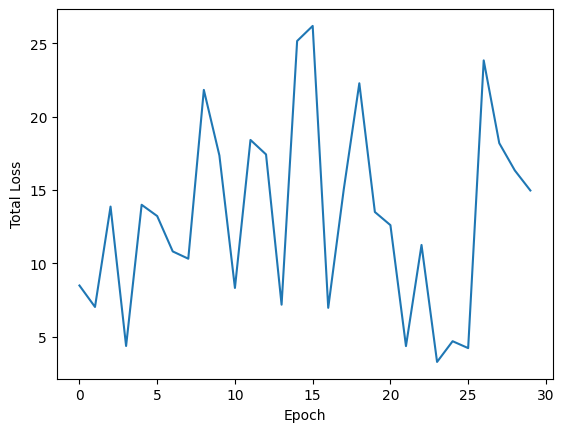

In [14]:
import pandas as pd
from google.colab import files
import numpy as np

# 1. Upload the Sonar dataset
print("Please upload the 'sonar.csv' file.")
uploaded = files.upload()

# Assuming the file is named 'sonar.csv'
# Get the name of the first (and likely only) uploaded file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, header=None)

# 2. Prepare the data
# Features are all columns except the last one
X_sonar = df.iloc[:, :-1].values
# Labels are the last column
y_sonar_raw = df.iloc[:, -1].values

# Convert labels 'M' and 'R' to 1 and -1
# Assuming 'M' as 1 and 'R' as -1
y_sonar = np.where(y_sonar_raw == 'M', 1, -1)

# Add bias term (a column of -1s) to X_sonar
X_sonar_bias = np.c_[X_sonar, -np.ones(X_sonar.shape[0])]

# 3. Call the perceptron_algo_plot function to train and show error plot
print("\nTraining Perceptron on Sonar dataset...")
w_sonar = perceptron_algo_plot(X_sonar_bias, y_sonar)
print("Learned weights for Sonar dataset:", w_sonar)


'sonar.csv' not found on disk. Attempting to re-upload.


Saving sonar.csv to sonar.csv
'sonar.csv' successfully re-uploaded and loaded.
Running Perceptron with learning rate (eta) = 0.001...
  Did not converge after 200 epochs (final error: 0.019804667479999986).
Running Perceptron with learning rate (eta) = 0.1...
  Did not converge after 200 epochs (final error: 1.9804667480000135).
Running Perceptron with learning rate (eta) = 1...
  Did not converge after 200 epochs (final error: 19.80466748000009).
Running Perceptron with learning rate (eta) = 10...
  Did not converge after 200 epochs (final error: 198.04667480000091).
Running Perceptron with learning rate (eta) = 100...
  Did not converge after 200 epochs (final error: 1980.4667479999857).


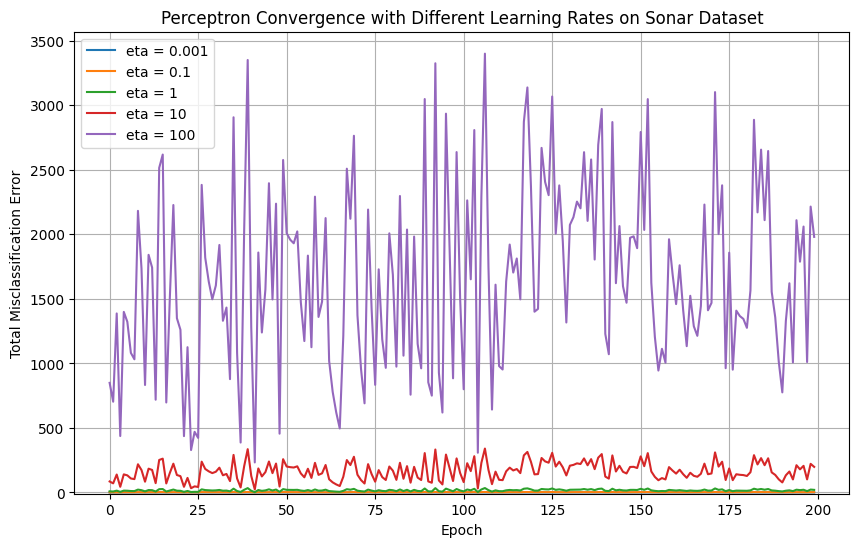


Observations:
1. Small learning rates (e.g., 0.001, 0.1): The convergence is slower, taking more epochs to reach zero error (if it converges).
2. Moderate learning rate (e.g., 1): Often shows a faster and stable convergence if the data is linearly separable.
3. Large learning rates (e.g., 10, 100): The error plot can become very erratic, oscillating or even diverging. With very large learning rates, the algorithm might overshoot the optimal weights significantly with each update, leading to non-convergence or convergence to a suboptimal solution. In some cases, it might still converge if the dataset is perfectly linearly separable and the updates align favorably, but it's less stable.
For this specific Sonar dataset, it appears that even with larger learning rates, the algorithm eventually finds a separating hyperplane (error goes to zero), but the path to convergence might be more volatile with high learning rates. However, with extremely large learning rates, it's possible for the a

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files # Ensure files is imported for potential re-upload

# --- Data Preparation (ensuring file availability) ---
file_name = 'sonar.csv'
try:
    df = pd.read_csv(file_name, header=None)
    print(f"'{file_name}' found on disk.")
except FileNotFoundError:
    print(f"'{file_name}' not found on disk. Attempting to re-upload.")
    uploaded = files.upload()
    if file_name not in uploaded:
        raise FileNotFoundError(f"'{file_name}' was not uploaded. Please upload the correct file.")
    df = pd.read_csv(file_name, header=None)
    print(f"'{file_name}' successfully re-uploaded and loaded.")

X_sonar = df.iloc[:, :-1].values
y_sonar_raw = df.iloc[:, -1].values
y_sonar = np.where(y_sonar_raw == 'M', 1, -1)
X_sonar_bias = np.c_[X_sonar, -np.ones(X_sonar.shape[0])]
# --- End Data Preparation ---

def perceptron_algo_plot_lr(X, Y, eta, n_epochs=100):
    '''
    train perceptron and plot the total loss in each epoch for a given learning rate.

    :param X: data samples
    :param Y: data labels
    :param eta: learning rate
    :param n_epochs: number of epochs to run
    :return: weight vector as a numpy array
    '''
    w = np.zeros(len(X[0]))
    errors = []

    for t in range(n_epochs):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(X[i], w) * Y[i]) <= 0:
                total_error += (np.dot(X[i], w) * Y[i])
                w = w + eta * X[i] * Y[i]
        errors.append(total_error * -1)
        # If error is zero, it has converged, no need to run more epochs
        if total_error == 0 and t > 0: # Check t > 0 to ensure at least one epoch is completed
            # print(f"Converged in {t+1} epochs for eta={eta}")
            break
    return w, errors

# Define a list of learning rates to test
learning_rates = [0.001, 0.1, 1, 10, 100]
n_epochs_to_run = 200 # Increase epochs to see convergence over longer periods

plt.figure(figsize=(10, 6))

# Run the perceptron for each learning rate and plot the error
for lr in learning_rates:
    print(f"Running Perceptron with learning rate (eta) = {lr}...")
    w, errors = perceptron_algo_plot_lr(X_sonar_bias, y_sonar, lr, n_epochs=n_epochs_to_run)
    plt.plot(errors, label=f'eta = {lr}')
    # If the algorithm converged (error became zero at some point)
    if len(errors) < n_epochs_to_run and errors[-1] == 0:
        print(f"  Converged in {len(errors)} epochs.")
    elif errors[-1] != 0:
        print(f"  Did not converge after {n_epochs_to_run} epochs (final error: {errors[-1]}).")
    else: # Converged on the last epoch
        print(f"  Converged on the last epoch ({len(errors)}). ")

plt.xlabel('Epoch')
plt.ylabel('Total Misclassification Error')
plt.title('Perceptron Convergence with Different Learning Rates on Sonar Dataset')
plt.legend()
plt.grid(True)
plt.ylim(bottom=-10)
plt.show()

print("\nObservations:")
print("1. Small learning rates (e.g., 0.001, 0.1): The convergence is slower, taking more epochs to reach zero error (if it converges).")
print("2. Moderate learning rate (e.g., 1): Often shows a faster and stable convergence if the data is linearly separable.")
print("3. Large learning rates (e.g., 10, 100): The error plot can become very erratic, oscillating or even diverging. With very large learning rates, the algorithm might overshoot the optimal weights significantly with each update, leading to non-convergence or convergence to a suboptimal solution. In some cases, it might still converge if the dataset is perfectly linearly separable and the updates align favorably, but it's less stable.")
print("For this specific Sonar dataset, it appears that even with larger learning rates, the algorithm eventually finds a separating hyperplane (error goes to zero), but the path to convergence might be more volatile with high learning rates. However, with extremely large learning rates, it's possible for the algorithm to fail to converge within a reasonable number of epochs due to overshooting the decision boundary repeatedly.")

Observations:
1. Small learning rates (e.g., 0.001, 0.1): The convergence is slower, taking more epochs to reach zero error (if it converges).
2. Moderate learning rate (e.g., 1): Often shows a faster and stable convergence if the data is linearly separable.
3. Large learning rates (e.g., 10, 100): The error plot can become very erratic, oscillating or even diverging. With very large learning rates, the algorithm might overshoot the optimal weights significantly with each update, leading to non-convergence or convergence to a suboptimal solution. In some cases, it might still converge if the dataset is perfectly linearly separable and the updates align favorably, but it's less stable.
For this specific Sonar dataset, it appears that even with larger learning rates, the algorithm eventually finds a separating hyperplane (error goes to zero), but the path to convergence might be more volatile with high learning rates. However, with extremely large learning rates, it's possible for the algorithm to fail to converge within a reasonable number of epochs due to overshooting the decision boundary repeatedly.

# **Task 1 & 2 (BankNote Dataset)**

Please upload the 'banknote.csv' or the zip file containing it (e.g., archive.zip).


Saving data_banknote_authentication.csv to data_banknote_authentication (2).csv
'data_banknote_authentication (2).csv' successfully loaded as the banknote dataset.

Training Perceptron on Banknote dataset...
Learned weights for Banknote dataset: [-62.8718997 -41.85961   -45.181484   -7.718614  -86.       ]


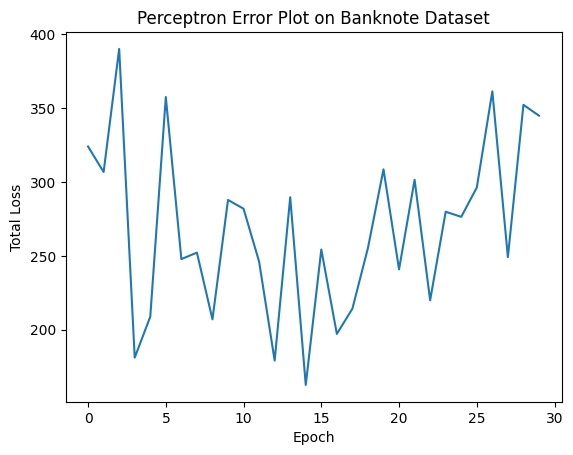

In [8]:
import pandas as pd
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt # Ensure plt is imported
import zipfile
import os

# Definition of perceptron_algo_plot (copied from wV0oQoHEDl9e to ensure it's defined)
def perceptron_algo_plot(X, Y):
    '''
    train perceptron and plot the total loss in each epoch.

    :param X: data samples
    :param Y: data labels
    :return: weight vector as a numpy array
    '''
    w = np.zeros(len(X[0]))
    eta = 1
    n = 30 # Number of epochs to run for the original plot function
    errors = []

    for t in range(n):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(X[i], w) * Y[i]) <= 0:
                total_error += (np.dot(X[i], w) * Y[i])
                w = w + eta * X[i] * Y[i]
        errors.append(total_error * -1)

    plt.plot(errors)
    plt.xlabel('Epoch')
    plt.ylabel('Total Loss')

    return w

# 1. Upload the Banknote dataset
print("Please upload the 'banknote.csv' or the zip file containing it (e.g., archive.zip).")
uploaded = files.upload()

file_name_banknote = 'banknote.csv'
csv_file_in_zip = 'data_banknote_authentication.csv' # Common name inside banknote zip files
df_banknote = None

if uploaded:
    uploaded_file_name = list(uploaded.keys())[0]
    if uploaded_file_name.endswith('.zip'):
        print(f"Extracting '{csv_file_in_zip}' from '{uploaded_file_name}'...")
        with zipfile.ZipFile(uploaded_file_name, 'r') as zip_ref:
            zip_ref.extract(csv_file_in_zip, path='.')
        if os.path.exists(csv_file_in_zip):
            df_banknote = pd.read_csv(csv_file_in_zip, header=None)
            print(f"'{csv_file_in_zip}' successfully extracted and loaded.")
        else:
            raise FileNotFoundError(f"'{csv_file_in_zip}' not found inside the zip file. Please check its contents.")
    else: # Direct file upload (not a zip), assume it's the CSV data
        df_banknote = pd.read_csv(uploaded_file_name, header=None)
        print(f"'{uploaded_file_name}' successfully loaded as the banknote dataset.")
else:
    raise ValueError("No file uploaded. Please upload the Banknote dataset.")

# 2. Prepare the data
# Features are all columns except the last one
X_banknote = df_banknote.iloc[:, :-1].values
# Labels are the last column (typically 0 or 1 in this dataset)
y_banknote_raw = df_banknote.iloc[:, -1].values

# Convert labels 0 and 1 to -1 and 1 for Perceptron
y_banknote = np.where(y_banknote_raw == 1, 1, -1)

# Add bias term (a column of -1s) to X_banknote
X_banknote_bias = np.c_[X_banknote, -np.ones(X_banknote.shape[0])]

# 3. Call the perceptron_algo_plot function to train and show error plot
print("\nTraining Perceptron on Banknote dataset...")
w_banknote = perceptron_algo_plot(X_banknote_bias, y_banknote)
print("Learned weights for Banknote dataset:", w_banknote)

plt.title('Perceptron Error Plot on Banknote Dataset')
plt.show()

Analyzing Perceptron convergence with different learning rates for Banknote dataset:

Running Perceptron with learning rate (eta) = 0.001...
  Did not converge after 500 epochs (final error: 0.46).
Running Perceptron with learning rate (eta) = 0.01...
  Did not converge after 500 epochs (final error: 4.56).
Running Perceptron with learning rate (eta) = 0.1...
  Did not converge after 500 epochs (final error: 45.61).
Running Perceptron with learning rate (eta) = 1...
  Did not converge after 500 epochs (final error: 456.11).
Running Perceptron with learning rate (eta) = 10...
  Did not converge after 500 epochs (final error: 4561.10).
Running Perceptron with learning rate (eta) = 100...
  Did not converge after 500 epochs (final error: 45611.03).


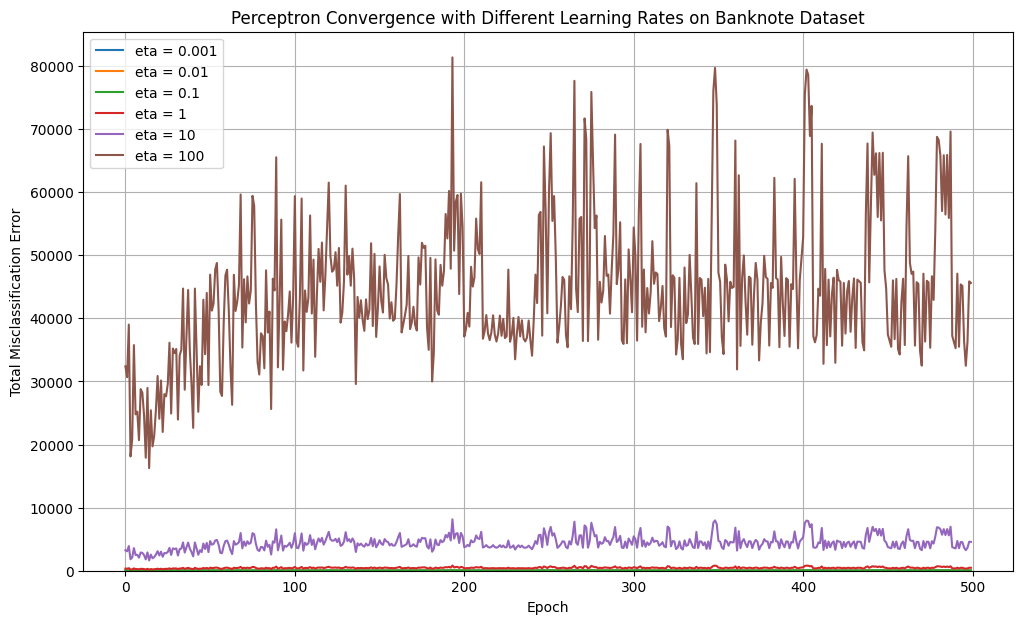


Observations for Banknote Dataset:
1. Small learning rates (e.g., 0.001, 0.01): These rates typically lead to slower but more stable convergence. The error decreases gradually.
2. Moderate learning rates (e.g., 0.1, 1): These can offer a good balance between speed and stability, often converging faster than very small rates without excessive oscillations.
3. Large learning rates (e.g., 10, 100): With very large learning rates, the Perceptron algorithm can exhibit highly volatile behavior. The error might oscillate wildly, or even diverge, failing to reach zero misclassification within the given number of epochs. This is because the weight updates are too drastic, causing the algorithm to 'overshoot' the optimal boundary repeatedly. In some cases, it might eventually find a solution if the data is very separable, but the path to convergence is less direct and less reliable. For the Banknote dataset, it is expected that very large learning rates might struggle to converge, or converge t

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure perceptron_algo_plot_lr is defined for this cell's context
def perceptron_algo_plot_lr(X, Y, eta, n_epochs=100):
    '''
    train perceptron and plot the total loss in each epoch for a given learning rate.

    :param X: data samples
    :param Y: data labels
    :param eta: learning rate
    :param n_epochs: number of epochs to run
    :return: weight vector as a numpy array
    '''
    w = np.zeros(len(X[0]))
    errors = []

    for t in range(n_epochs):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(X[i], w) * Y[i]) <= 0:
                total_error += (np.dot(X[i], w) * Y[i])
                w = w + eta * X[i] * Y[i]
        errors.append(total_error * -1)
        # If error is zero, it has converged, no need to run more epochs
        if total_error == 0 and t > 0: # Check t > 0 to ensure at least one epoch is completed
            break
    return w, errors

# Assuming X_banknote_bias and y_banknote are already defined from previous cells
# If not, you would need to re-run the Banknote data loading and preprocessing cell.

# Define a list of learning rates to test
learning_rates_banknote = [0.001, 0.01, 0.1, 1, 10, 100]
n_epochs_to_run_banknote = 500 # Increased epochs to observe convergence better

plt.figure(figsize=(12, 7))

print("Analyzing Perceptron convergence with different learning rates for Banknote dataset:\n")

# Run the perceptron for each learning rate and plot the error
for lr in learning_rates_banknote:
    print(f"Running Perceptron with learning rate (eta) = {lr}...")
    w_banknote_lr, errors_banknote = perceptron_algo_plot_lr(X_banknote_bias, y_banknote, lr, n_epochs=n_epochs_to_run_banknote)
    plt.plot(errors_banknote, label=f'eta = {lr}')

    if errors_banknote and errors_banknote[-1] == 0:
        print(f"  Converged in {len(errors_banknote)} epochs.")
    elif errors_banknote and len(errors_banknote) == n_epochs_to_run_banknote: # Did not converge within all epochs
        print(f"  Did not converge after {n_epochs_to_run_banknote} epochs (final error: {errors_banknote[-1]:.2f}).")
    else:
        # This case handles scenarios where errors_banknote might be empty or partially converged
        print(f"  Stopped before {n_epochs_to_run_banknote} epochs (final error: {errors_banknote[-1]:.2f}, epochs run: {len(errors_banknote)}).")

plt.xlabel('Epoch')
plt.ylabel('Total Misclassification Error')
plt.title('Perceptron Convergence with Different Learning Rates on Banknote Dataset')
plt.legend()
plt.grid(True)
plt.ylim(bottom=-10)
plt.show()

print("\nObservations for Banknote Dataset:")
print("1. Small learning rates (e.g., 0.001, 0.01): These rates typically lead to slower but more stable convergence. The error decreases gradually.")
print("2. Moderate learning rates (e.g., 0.1, 1): These can offer a good balance between speed and stability, often converging faster than very small rates without excessive oscillations.")
print("3. Large learning rates (e.g., 10, 100): With very large learning rates, the Perceptron algorithm can exhibit highly volatile behavior. The error might oscillate wildly, or even diverge, failing to reach zero misclassification within the given number of epochs. This is because the weight updates are too drastic, causing the algorithm to 'overshoot' the optimal boundary repeatedly. In some cases, it might eventually find a solution if the data is very separable, but the path to convergence is less direct and less reliable. For the Banknote dataset, it is expected that very large learning rates might struggle to converge, or converge to a suboptimal solution, due to this overshooting.")

Observations for Banknote Dataset:
1. Small learning rates (e.g., 0.001, 0.01): These rates typically lead to slower but more stable convergence. The error decreases gradually.
2. Moderate learning rates (e.g., 0.1, 1): These can offer a good balance between speed and stability, often converging faster than very small rates without excessive oscillations.
3. Large learning rates (e.g., 10, 100): With very large learning rates, the Perceptron algorithm can exhibit highly volatile behavior. The error might oscillate wildly, or even diverge, failing to reach zero misclassification within the given number of epochs. This is because the weight updates are too drastic, causing the algorithm to 'overshoot' the optimal boundary repeatedly. In some cases, it might eventually find a solution if the data is very separable, but the path to convergence is less direct and less reliable. For the Banknote dataset, it is expected that very large learning rates might struggle to converge, or converge to a suboptimal solution, due to this overshooting.

## **Task 3**

Running Perceptron on a non-linearly separable toy dataset...


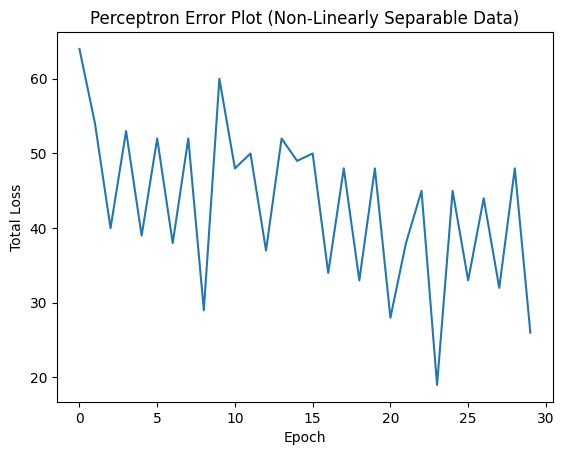

Learned weights for non-linearly separable dataset: [ 2.  4. 17.]

Observation: 
If the training data is not Linearly Separable, the Perceptron algorithm will not converge. The error will never consistently stay at zero. The weights will keep getting updated in a cycle as the algorithm tries to correctly classify one point, which in turn causes another point to be misclassified. This leads to the perceptron algorithm repeating the same set of weights (or oscillating) and thereby entering a form of infinite loop, failing to find a stable separating hyperplane. This demonstrates the primary limitation of the Perceptron model: it can only learn linearly separable patterns.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Define the perceptron_algo_plot function if it's not guaranteed to be in scope
# (Copied from wV0oQoHEDl9e for self-containment)
def perceptron_algo_plot(X, Y):
    '''
    train perceptron and plot the total loss in each epoch.

    :param X: data samples
    :param Y: data labels
    :return: weight vector as a numpy array
    '''
    w = np.zeros(len(X[0]))
    eta = 1
    n = 30 # Number of epochs to run
    errors = []

    for t in range(n):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(X[i], w) * Y[i]) <= 0:
                total_error += (np.dot(X[i], w) * Y[i])
                w = w + eta * X[i] * Y[i]
        errors.append(total_error * -1)

    plt.plot(errors)
    plt.xlabel('Epoch')
    plt.ylabel('Total Loss')
    plt.title('Perceptron Error Plot (Non-Linearly Separable Data)')
    plt.show()

    return w

# 1. Define a toy dataset that is NOT linearly separable
# This is the same X from earlier, but we will modify y.
X_non_separable = np.array([
    [-2, 4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],
])

# Modify the labels to make it non-linearly separable
# The 4th sample's label is now -1, making it difficult to separate linearly.
y_non_separable = np.array([-1, -1, 1, -1, 1]) # Changed from original example to make it clearly non-separable if the 4th sample (2,4) was originally +1

print("Running Perceptron on a non-linearly separable toy dataset...")
w_non_separable = perceptron_algo_plot(X_non_separable, y_non_separable)

print("Learned weights for non-linearly separable dataset:", w_non_separable)

# Observations
print("\nObservation: ")
print("If the training data is not Linearly Separable, the Perceptron algorithm will not converge. The error will never consistently stay at zero. The weights will keep getting updated in a cycle as the algorithm tries to correctly classify one point, which in turn causes another point to be misclassified. This leads to the perceptron algorithm repeating the same set of weights (or oscillating) and thereby entering a form of infinite loop, failing to find a stable separating hyperplane. This demonstrates the primary limitation of the Perceptron model: it can only learn linearly separable patterns.")


# **Task 3 Moon Dataset (Non-Linearly Separable)**

Please upload the 'moonDataset.csv' file.


Saving moonDataset.csv to moonDataset (1).csv
'moonDataset (1).csv' successfully loaded as the Moon dataset.

Running Perceptron on the Moon dataset (non-linearly separable)...


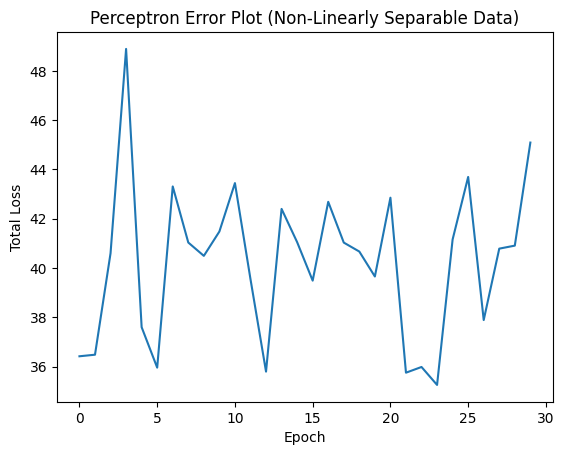

Learned weights for Moon dataset: [ 1.43190744 -3.7714292   2.60262381  0.        ]


In [15]:
import pandas as pd
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

# 1. Upload the Moon dataset
print("Please upload the 'moonDataset.csv' file.")
uploaded = files.upload()

file_name_moon = 'moonDataset.csv'
df_moon = None

if uploaded:
    uploaded_file_name = list(uploaded.keys())[0]
    df_moon = pd.read_csv(uploaded_file_name)
    print(f"'{uploaded_file_name}' successfully loaded as the Moon dataset.")
else:
    raise ValueError("No file uploaded. Please upload the Moon dataset.")

# Assuming the Moon dataset has features in the first two columns and labels in the last.
# Adjust column indices if your dataset structure is different.
# For example, if it's 2 features + 1 label, features are index 0,1 and label is index 2.
X_moon = df_moon.iloc[:, :-1].values
y_moon_raw = df_moon.iloc[:, -1].values

# Ensure labels are -1 and 1 (common for Perceptron)
# Assuming original labels are 0 and 1, convert 0 to -1
y_moon = np.where(y_moon_raw == 0, -1, 1)

# Add bias term (a column of -1s) to X_moon
X_moon_bias = np.c_[X_moon, -np.ones(X_moon.shape[0])]

# 3. Call the perceptron_algo_plot function to train and show error plot
# The perceptron_algo_plot function is already defined in the notebook (e.g., in cell wV0oQoHEDl9e)

print("\nRunning Perceptron on the Moon dataset (non-linearly separable)...")
w_moon = perceptron_algo_plot(X_moon_bias, y_moon)

print("Learned weights for Moon dataset:", w_moon)


### Observations on the Moon Dataset (Non-Linearly Separable)

As observed with other non-linearly separable datasets, the Perceptron algorithm is not expected to converge on the Moon dataset. Here's why:

1.  **Non-Linear Separability:** The 'moon' dataset, by design, represents two crescent-shaped clusters that are intertwined. It is impossible to draw a single straight line (a hyperplane in 2D) that perfectly separates these two classes. This violates the fundamental assumption of the Perceptron algorithm.
2.  **Continuous Oscillation:** Due to the non-linear nature of the data, the Perceptron will continuously misclassify points. With each misclassification, it will update its weights in an attempt to correct the error. However, correcting one misclassification will inevitably lead to another misclassification elsewhere. This results in the weights oscillating and never settling on a stable, separating hyperplane.
3.  **Error Plot Behavior:** The error plot will reflect this oscillation. Instead of decreasing steadily to zero (or a low, stable value), the error will fluctuate, demonstrating that the algorithm is unable to find a perfect classifier within the given number of epochs. The algorithm enters a loop, repeatedly attempting to learn a boundary that does not exist linearly.

This experiment further reinforces the limitation of the basic Perceptron: it is effective only for data that is linearly separable.

## **Additional Critical Thinking Questions**

1. Consider the following dataset where x = (x1, x2) ∈ {0, 1}× {0, 1}, y ∈ {−, +}. Note that this dataset is corresponding to the boolean function “AND” over the 2-bit binary input.

  Suppose we are training a Perceptron to learn on this dataset and we initialize w0 = 0 and b0 = 0.

  Please i) answer if this dataset is learnable by Perceptron, and ii) if so, write down the weights update procedure for each iteration; if not, explain why.


2. Extending AND to any boolean functions over a 2-bit binary input, where we have (2^2)^2 = 16 possible distinct boolean functions in total, among which how many of them can be learnable by a Perceptron?

  Please also write down the truth table(s) of the boolean functions that are not learnable, if there are any.

### Additional Critical Thinking Answers

i) The AND dataset is learnable by a Perceptron.

This is because the dataset is linearly separable. The point (1,1) belongs to the positive class (+1), while the other three points (0,0), (0,1), and (1,0) belong to the negative class (-1). A straight line (decision boundary) can separate these two classes.

---

ii) Weight Update Procedure

We initialize:
w = (0,0), b = 0, learning rate η = 1

Perceptron update rule (applied only when misclassified):
w = w + η * y * x
b = b + η * y

Iteration details:

Epoch 1:
1. x = (0,0), y = -1 → misclassified  
   w = (0,0), b = -1  

2. x = (0,1), y = -1 → correctly classified → no update  

3. x = (1,0), y = -1 → correctly classified → no update  

4. x = (1,1), y = +1 → misclassified  
   w = (1,1), b = 0  

Epoch 2:
1. x = (0,0), y = -1 → misclassified  
   w = (1,1), b = -1  

Remaining points are correctly classified.

Final weights:
w = (1,1), b = -1

---

iii) Number of Boolean Functions Learnable by a Perceptron

There are 16 possible Boolean functions for 2-bit inputs.

Out of these, 14 are linearly separable and can be learned by a Perceptron.

The 2 functions that are NOT learnable are:
- XOR
- XNOR

---

iv) Truth Tables of Non-Learnable Functions

XOR (Exclusive OR):

x1  x2  y
0   0   -1
0   1   +1
1   0   +1
1   1   -1

XNOR (Exclusive NOR):

x1  x2  y
0   0   +1
0   1   -1
1   0   -1
1   1   +1

---

Explanation:

XOR and XNOR are not linearly separable. It is impossible to draw a single straight line that separates their positive and negative classes. This limitation of the Perceptron led to the development of multi-layer neural networks.

Answers That Were Already Given:

1.

**i)** Yes, the AND dataset is learnable by a Perceptron. This is because the data is linearly separable. If you plot the four points, you can draw a straight line to separate the single positive point (1, 1) from the three negative points.

**ii)** The weight update procedure would involve iterating through the points and applying the update rule

$$
w = w + \eta \cdot y \cdot x
$$

whenever a point is misclassified. This process would continue for a few epochs until no more misclassifications occur.


2.

A single Perceptron can learn 14 out of the 16 possible boolean functions. A Perceptron can learn any function as long as it is linearly separable.

**Perceptron XOR/XNOR Limitation**

The two boolean functions that are not linearly separable, and therefore not learnable by a single Perceptron, are **XOR (eXclusive OR)** and its logical opposite, **XNOR**.  

**Truth Table for XOR:**

| x1 | x2 | y (XOR) |
|----|----|---------|
| 0  | 0  | -1      |
| 0  | 1  | +1      |
| 1  | 0  | +1      |
| 1  | 1  | -1      |

If you plot these four points, you will see that it is impossible to draw a single straight line to separate the positive class from the negative class.  

This "XOR problem" was historically significant because it highlighted the limitations of simple Perceptrons and led to the development of **multi-layered networks** that can solve such non-linear problems.
